# 04 — Multinomial Naive Bayes

**Mục tiêu:**
- Huấn luyện mô hình Multinomial Naive Bayes cho bài toán phân loại tin giả.
- Sử dụng GridSearchCV để tìm kiếm siêu tham số tối ưu cho `alpha` và `fit_prior` với K-Fold Cross Validation (cv=5).
- Đánh giá mô hình trên tập Validation (Accuracy, Precision, Recall, F1-Score, Confusion Matrix).
- Vẽ đồ thị thể hiện sự ảnh hưởng của tham số `alpha` tới độ chính xác (Accuracy / F1-Score) của mô hình.
- Lưu mô hình tối ưu nhất phục vụ cho các bước so sánh tiếp theo.

**Input:** `data/X_*_tfidf.pkl`, `data/y_*.pkl`  
**Output:** `models/naive_bayes_model.pkl`

## 1. Import các thư viện cần thiết

In [1]:
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load dữ liệu đã Vector hóa từ Tuần 1

In [2]:
DATA_DIR = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

X_train = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
X_val = joblib.load(DATA_DIR / 'X_val_tfidf.pkl')
y_train = np.array(joblib.load(DATA_DIR / 'y_train.pkl'))
y_val = np.array(joblib.load(DATA_DIR / 'y_val.pkl'))

print(f"Bộ dữ liệu đang dùng: {DATA_DIR.resolve()}")
print("Kích thước tập dữ liệu:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
train_labels, train_counts = np.unique(y_train, return_counts=True)
val_labels, val_counts = np.unique(y_val, return_counts=True)
print("Phân phối nhãn train:", dict(zip(train_labels.tolist(), train_counts.tolist())))
print("Phân phối nhãn val  :", dict(zip(val_labels.tolist(), val_counts.tolist())))

Bộ dữ liệu đang dùng: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/data
Kích thước tập dữ liệu:
  X_train : (27057, 5000)
  X_val   : (5798, 5000)
Phân phối nhãn train: {0: 14837, 1: 12220}
Phân phối nhãn val  : {0: 3179, 1: 2619}


## 3. Chạy GridSearchCV tìm tham số tối ưu

Không gian tham số tìm kiếm:
- `alpha`: [0.01, 0.1, 0.5, 1.0, 2.0] (Laplace smoothing parameter)
- `fit_prior`: [True, False] (Có học xác suất tiên nghiệm từ dữ liệu hay không)

In [3]:
nb_model = MultinomialNB()

param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Bắt đầu quá trình Grid Search...")
t0 = time.time()
grid_search.fit(X_train, y_train)
training_time = time.time() - t0

print(f"Hoàn thành Grid Search sau: {training_time:.2f} giây.")
print("Tham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Accuracy tốt nhất trên Cross-Validation: {grid_search.best_score_:.4f}")

Bắt đầu quá trình Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Hoàn thành Grid Search sau: 1.63 giây.
Tham số tốt nhất tìm được: {'alpha': 0.01, 'fit_prior': True}
Accuracy tốt nhất trên Cross-Validation: 0.9429


## 4. Đánh giá mô hình tốt nhất trên tập Validation

In [4]:
best_nb_model = grid_search.best_estimator_
y_pred = best_nb_model.predict(X_val)

print("===== BÁO CÁO PHÂN LOẠI (VALIDATION SET) =====")
print(classification_report(y_val, y_pred, target_names=['REAL (0)', 'FAKE (1)']))

val_accuracy = accuracy_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, average='weighted')
print(f"Accuracy trên Val Set: {val_accuracy:.4f}")
print(f"F1-score (weighted) trên Val Set: {val_f1:.4f}")

===== BÁO CÁO PHÂN LOẠI (VALIDATION SET) =====
              precision    recall  f1-score   support

    REAL (0)       0.95      0.94      0.95      3179
    FAKE (1)       0.93      0.94      0.94      2619

    accuracy                           0.94      5798
   macro avg       0.94      0.94      0.94      5798
weighted avg       0.94      0.94      0.94      5798

Accuracy trên Val Set: 0.9415
F1-score (weighted) trên Val Set: 0.9416


### Ma trận nhầm lẫn (Confusion Matrix)

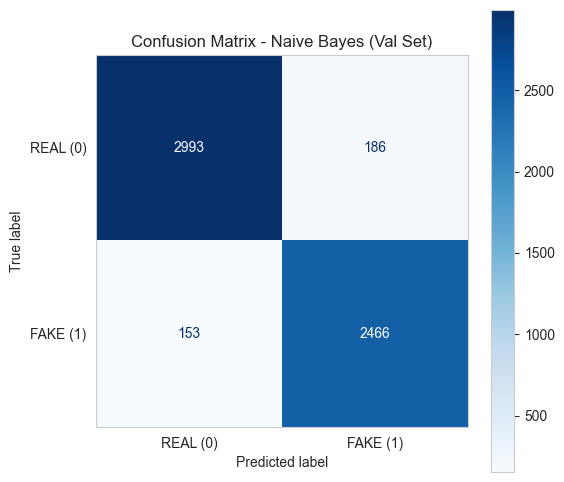

In [5]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL (0)', 'FAKE (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Naive Bayes (Val Set)")
plt.grid(False)
plt.show()

## 5. Lưu mô hình đã huấn luyện

In [6]:
model_path = MODELS_DIR / 'naive_bayes_model.pkl'
joblib.dump(best_nb_model, model_path)
print(f"Đã lưu mô hình Naive Bayes tốt nhất vào: {model_path}")

Đã lưu mô hình Naive Bayes tốt nhất vào: ../models/naive_bayes_model.pkl


## 6. Vẽ đồ thị thể hiện sự thay đổi hiệu năng theo tham số alpha

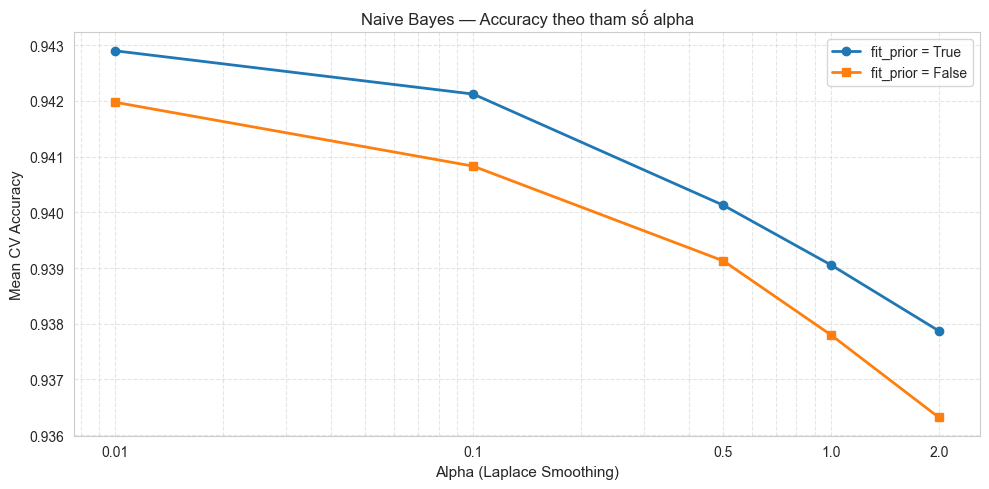

Đã lưu biểu đồ tuning tham số vào: reports/naive_bayes_alpha_tuning.png


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)

# Trích xuất kết quả cho hai trường hợp fit_prior=True và fit_prior=False
results_true = cv_results[cv_results['param_fit_prior'] == True].sort_values(by='param_alpha')
results_false = cv_results[cv_results['param_fit_prior'] == False].sort_values(by='param_alpha')

plt.figure(figsize=(10, 5))
plt.plot(results_true['param_alpha'].astype(float), results_true['mean_test_score'], marker='o', label='fit_prior = True', linewidth=2)
plt.plot(results_false['param_alpha'].astype(float), results_false['mean_test_score'], marker='s', label='fit_prior = False', linewidth=2)

plt.title('Naive Bayes — Accuracy theo tham số alpha', fontsize=12)
plt.xlabel('Alpha (Laplace Smoothing)', fontsize=11)
plt.ylabel('Mean CV Accuracy', fontsize=11)
plt.xscale('log')  # Dùng thang đo log để hiển thị rõ các khoảng cách alpha
plt.xticks([0.01, 0.1, 0.5, 1.0, 2.0], ['0.01', '0.1', '0.5', '1.0', '2.0'])
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/naive_bayes_alpha_tuning.png', dpi=150)
plt.show()

print("Đã lưu biểu đồ tuning tham số vào: reports/naive_bayes_alpha_tuning.png")